In [1]:
%pip install -r req.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importar as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import sys

logging.basicConfig(
    level=logging.ERROR,
    format='%(levelname)s - %(message)s',
    force=True,
    handlers=[logging.StreamHandler(sys.stdout)]
)

In [3]:
# Configurar o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Ler os dados (ignorando o cabeçalho do INMET)
df_2022 = pd.read_csv("dataset/clima/NITEROI 2022.CSV", sep=";", skiprows=8, encoding="latin1")
df_2023 = pd.read_csv("dataset/clima/NITEROI 2023.CSV", sep=";", skiprows=8, encoding="latin1")
df_2024 = pd.read_csv("dataset/clima/NITEROI 2024.CSV", sep=";", skiprows=8, encoding="latin1")
df_2025 = pd.read_csv("dataset/clima/NITEROI 2025.CSV", sep=";", skiprows=8, encoding="latin1")

# Unir os dados num único DataFrame
df = pd.concat([df_2022, df_2023, df_2024, df_2025], ignore_index=True)

# Remover a coluna vazia gerada pelo ponto e vírgula no final das linhas
if 'Unnamed: 19' in df.columns:
    df = df.drop(columns=['Unnamed: 19'])

In [4]:
df.head()

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2022/01/01,0000 UTC,0,"1008,8","1008,8","1008,2",NaN,"24,7","22,6",25,"24,7","22,8","22,4",89.0,86.0,88.0,66.0,"4,6","1,4"
1,2022/01/01,0100 UTC,",2",1009,"1009,1","1008,7",NaN,"24,6","22,3",25,"24,6","22,7","22,1",89.0,84.0,87.0,74.0,"5,2",",7"
2,2022/01/01,0200 UTC,",4","1009,3","1009,6",1009,NaN,"23,4","23,3","24,7","23,3","23,3","22,1",100.0,86.0,100.0,39.0,"2,1",",3"
3,2022/01/01,0300 UTC,",2","1007,9","1009,4","1007,9",NaN,24,"21,1","24,2","23,1","23,3","21,1",100.0,83.0,84.0,75.0,"6,2","2,4"
4,2022/01/01,0400 UTC,0,"1007,5","1007,9","1007,5",NaN,"23,9","20,5",24,"22,9","21,9","20,2",94.0,79.0,81.0,53.0,"6,2","1,3"


# 3. Engenharia de Atributos Temporais
Extração do mês e da hora para que a I.A consiga aprender os ciclos temporais. As colunas originais de texto são descartadas.

In [5]:
# Verificamos se as colunas ainda existem no DataFrame
if 'Data' in df.columns and 'Hora UTC' in df.columns:
    
    try:
        # Pega a posição (índice numérico) da coluna 'Data' original
        idx_data = df.columns.get_loc('Data')
        
        # Converte a data, extrai o mês e insere a coluna 'MES' na mesma posição
        mes_series = pd.to_datetime(df['Data']).dt.month
        df.insert(idx_data, 'MES', mes_series)
        
    except Exception as e:
        logging.error(f"Erro ao converter a coluna de Data: {e}")
    
    try:
        # Como adicionamos uma coluna, calculamos a posição de 'Hora UTC'
        idx_hora = df.columns.get_loc('Hora UTC')
        
        # Extrai a hora e insere a coluna 'HORA' na mesma posição
        hora_series = df['Hora UTC'].astype(str).str.replace(' UTC', '').astype(int) // 100
        df.insert(idx_hora, 'HORA', hora_series)
        
    except Exception as e:
        logging.error(f"Erro ao extrair a Hora: {e}")

    # Descartar as colunas originais de texto rigorosamente
    df = df.drop(columns=['Data', 'Hora UTC'])
    print("Sucesso: Colunas de tempo processadas, substituídas no mesmo lugar e descartadas.")

else:
    print("As colunas 'Data' e 'Hora UTC' já foram processadas anteriormente.")

Sucesso: Colunas de tempo processadas, substituídas no mesmo lugar e descartadas.


In [6]:
df.head()

,MES,HORA,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,1,0,0,"1008,8","1008,8","1008,2",NaN,"24,7","22,6",25,"24,7","22,8","22,4",89.0,86.0,88.0,66.0,"4,6","1,4"
1,1,1,",2",1009,"1009,1","1008,7",NaN,"24,6","22,3",25,"24,6","22,7","22,1",89.0,84.0,87.0,74.0,"5,2",",7"
2,1,2,",4","1009,3","1009,6",1009,NaN,"23,4","23,3","24,7","23,3","23,3","22,1",100.0,86.0,100.0,39.0,"2,1",",3"
3,1,3,",2","1007,9","1009,4","1007,9",NaN,24,"21,1","24,2","23,1","23,3","21,1",100.0,83.0,84.0,75.0,"6,2","2,4"
4,1,4,0,"1007,5","1007,9","1007,5",NaN,"23,9","20,5",24,"22,9","21,9","20,2",94.0,79.0,81.0,53.0,"6,2","1,3"


# Tratamento de Decimais
Substituição das vírgulas por pontos nas variáveis atmosféricas. Qualquer falha de conversão numérica (como um erro no sensor do INMET) será registada no log em vez de passar despercebida.

In [7]:
# Seleciona apenas as colunas que ainda são texto, incluindo 'str'
colunas_texto = df.select_dtypes(include=['object', 'str']).columns

for col in colunas_texto:
    # Troca a vírgula pelo ponto
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    
    # Tenta converter para numérico. Se falhar, captura e regista o erro.
    try:
        df[col] = pd.to_numeric(df[col])
    except ValueError as e:
        logging.error(f"Falha de conversão numérica na coluna '{col}': {e}")

# Remover linhas onde a precipitação (nosso alvo) seja estritamente nula
df = df.dropna(subset=['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'])

In [8]:
df.head()

,MES,HORA,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,1,0,0.0,1008.8,1008.8,1008.2,NaN,24.7,22.6,25.0,24.7,22.8,22.4,89.0,86.0,88.0,66.0,4.6,1.4
1,1,1,0.2,1009.0,1009.1,1008.7,NaN,24.6,22.3,25.0,24.6,22.7,22.1,89.0,84.0,87.0,74.0,5.2,0.7
2,1,2,0.4,1009.3,1009.6,1009.0,NaN,23.4,23.3,24.7,23.3,23.3,22.1,100.0,86.0,100.0,39.0,2.1,0.3
3,1,3,0.2,1007.9,1009.4,1007.9,NaN,24.0,21.1,24.2,23.1,23.3,21.1,100.0,83.0,84.0,75.0,6.2,2.4
4,1,4,0.0,1007.5,1007.9,1007.5,NaN,23.9,20.5,24.0,22.9,21.9,20.2,94.0,79.0,81.0,53.0,6.2,1.3


# Criação da Variável Alvo

In [9]:
# Renomeia a coluna original para um nome mais curto e limpo
if 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)' in df.columns:
    df = df.rename(columns={'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PRECIPITACAO'})

# Cria as condições agrupando tudo que é maior que 5.0 mm/h na classe 2
condicoes = [
    (df['PRECIPITACAO'] == 0.0),
    (df['PRECIPITACAO'] > 0.0) & (df['PRECIPITACAO'] <= 5.0),
    (df['PRECIPITACAO'] > 5.0)
]

# Calcula os valores: 0 (Sem chuva), 1 (Fraca), 2 (Moderada a Muito Forte)
valores_classes = np.select(condicoes, [0, 1, 2], default=0)

# Descobre a posição exata da coluna 'PRECIPITACAO'
idx_precipitacao = df.columns.get_loc('PRECIPITACAO')

# Remove a coluna se ela já existir de execuções anteriores (evita erro no Jupyter)
if 'CLASSIFICACAO_CHUVA' in df.columns:
    df = df.drop(columns=['CLASSIFICACAO_CHUVA'])

# Insere a nova coluna 'CLASSIFICACAO_CHUVA' logo após a 'PRECIPITACAO' (índice + 1)
df.insert(idx_precipitacao + 1, 'CLASSIFICACAO_CHUVA', valores_classes)

# Verificação final da distribuição das classes
print(df['CLASSIFICACAO_CHUVA'].value_counts())

# Exibe as primeiras linhas para confirmar se ficou lado a lado
df.head()

CLASSIFICACAO_CHUVA
0    32303
1     2264
2      166
Name: count, dtype: int64


,MES,HORA,PRECIPITACAO,CLASSIFICACAO_CHUVA,"PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,1,0,0.0,0,1008.8,1008.8,1008.2,NaN,24.7,22.6,25.0,24.7,22.8,22.4,89.0,86.0,88.0,66.0,4.6,1.4
1,1,1,0.2,1,1009.0,1009.1,1008.7,NaN,24.6,22.3,25.0,24.6,22.7,22.1,89.0,84.0,87.0,74.0,5.2,0.7
2,1,2,0.4,1,1009.3,1009.6,1009.0,NaN,23.4,23.3,24.7,23.3,23.3,22.1,100.0,86.0,100.0,39.0,2.1,0.3
3,1,3,0.2,1,1007.9,1009.4,1007.9,NaN,24.0,21.1,24.2,23.1,23.3,21.1,100.0,83.0,84.0,75.0,6.2,2.4
4,1,4,0.0,0,1007.5,1007.9,1007.5,NaN,23.9,20.5,24.0,22.9,21.9,20.2,94.0,79.0,81.0,53.0,6.2,1.3


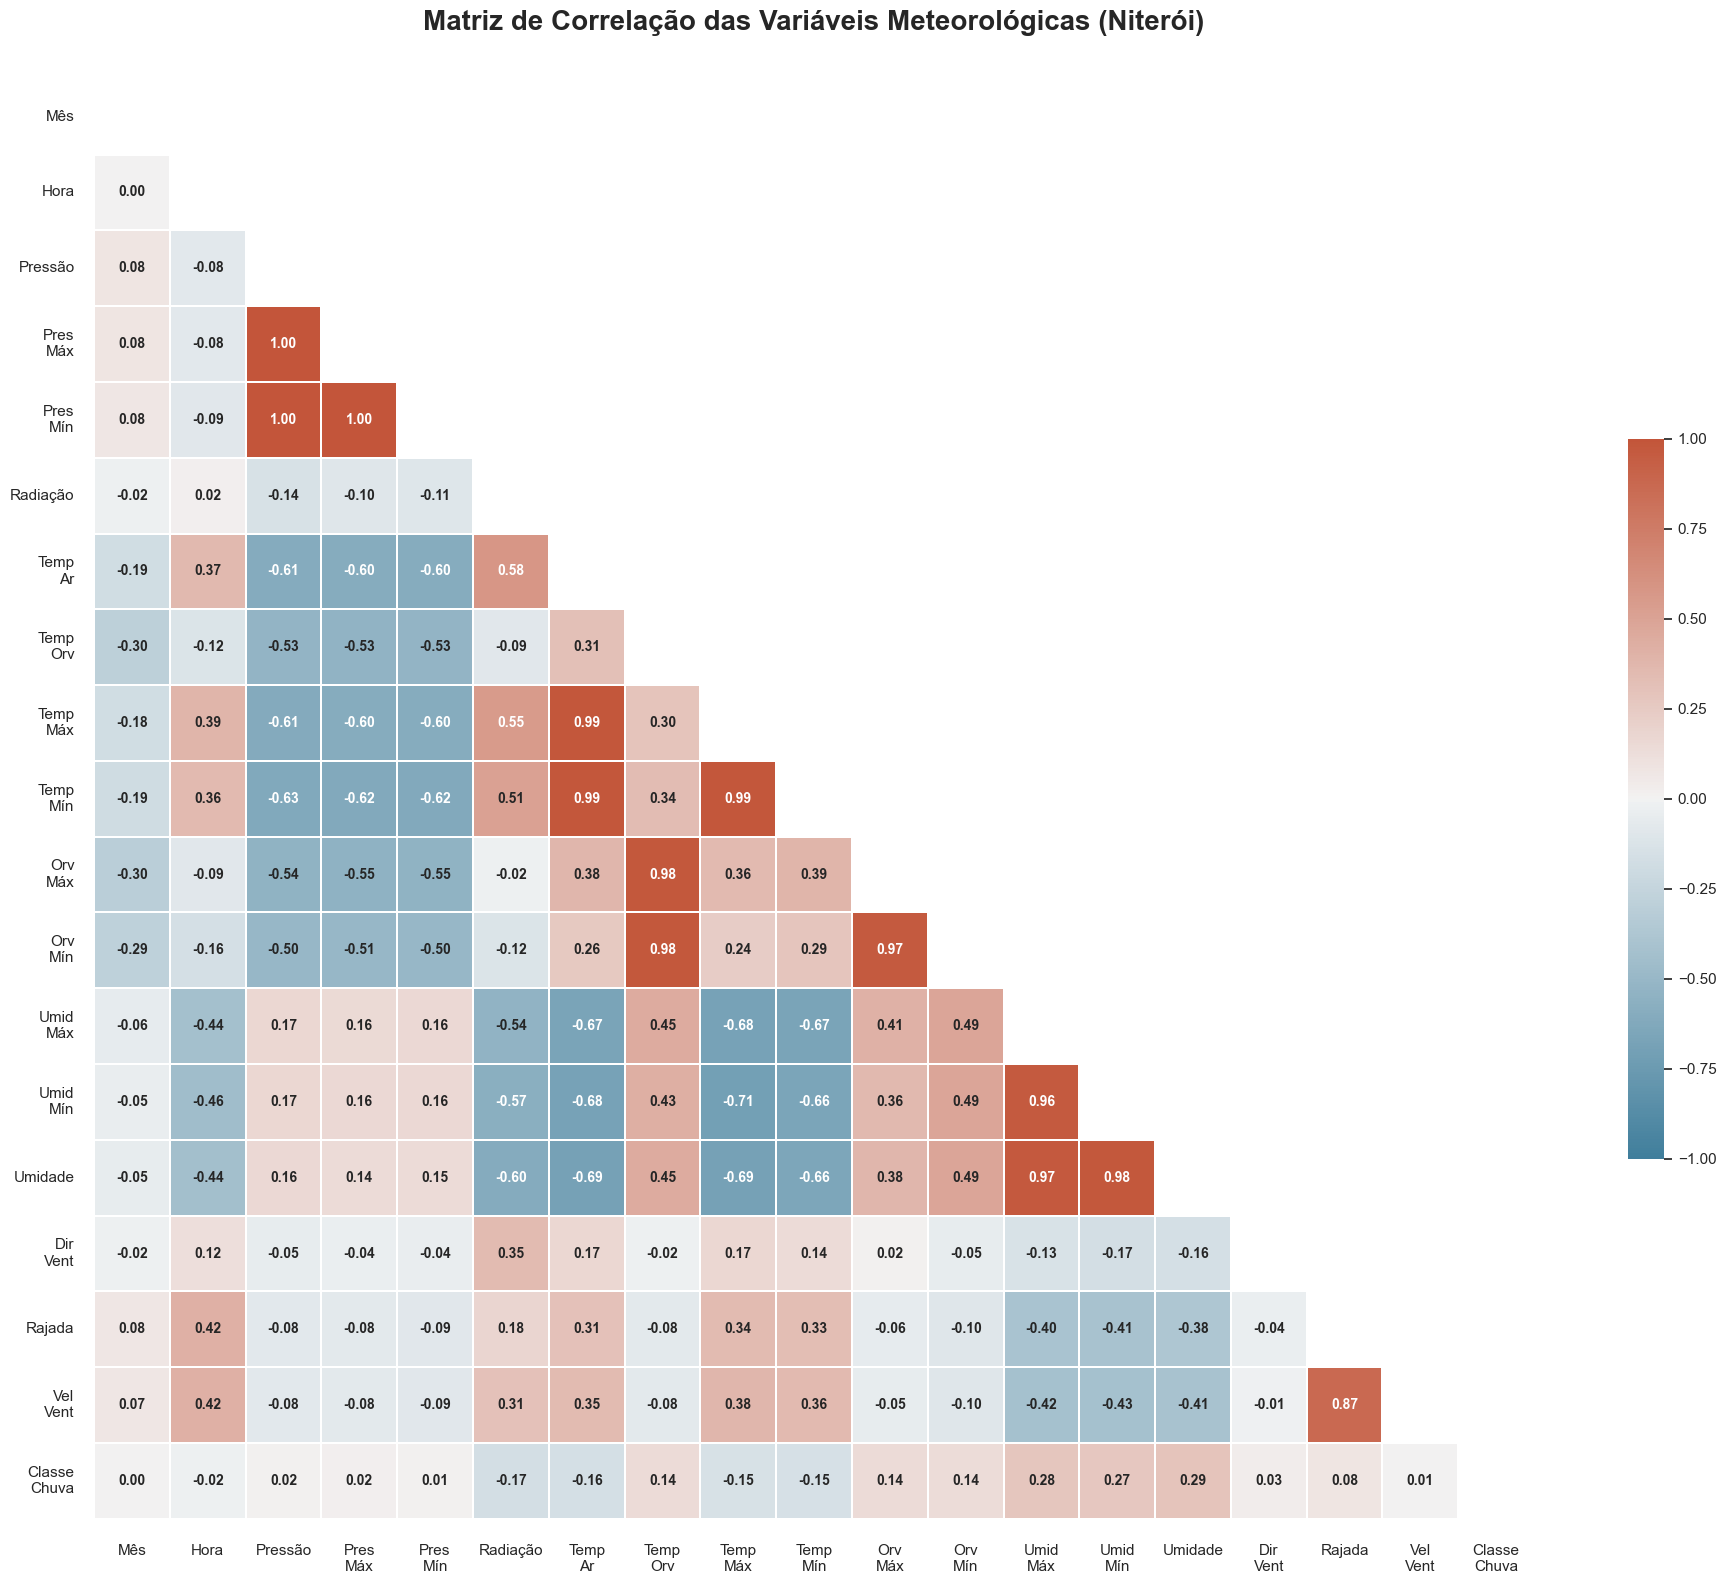

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dicionário com quebras de linha (\n)
nomes_curtos = {
    'MES': 'Mês',
    'HORA': 'Hora',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'Pressão',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'Pres\nMáx',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'Pres\nMín',
    'RADIACAO GLOBAL (Kj/m²)': 'Radiação',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'Temp\nAr',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'Temp\nOrv',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'Temp\nMáx',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'Temp\nMín',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'Orv\nMáx',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'Orv\nMín',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'Umid\nMáx',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'Umid\nMín',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'Umidade',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'Dir\nVent',
    'VENTO, RAJADA MAXIMA (m/s)': 'Rajada',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'Vel\nVent',
    'CLASSIFICACAO_CHUVA': 'Classe\nChuva'
}

# Remove a coluna contínua para evitar Data Leakage
df_correlacao = df.drop(columns=['PRECIPITACAO'], errors='ignore')

# REORGANIZAÇÃO: Garante que o Alvo vá para a última coluna do DataFrame
if 'CLASSIFICACAO_CHUVA' in df_correlacao.columns:
    cols = [c for c in df_correlacao.columns if c != 'CLASSIFICACAO_CHUVA'] + ['CLASSIFICACAO_CHUVA']
    df_correlacao = df_correlacao[cols]

# 2. Matriz de Correlação com os nomes modificados
matriz_corr = df_correlacao.rename(columns=nomes_curtos).corr()

# Zera tudo que arredondaria para 0.00 (evita -0.00)
matriz_corr[np.abs(matriz_corr) < 0.005] = 0.0
matriz_corr = matriz_corr + 0.0

# 3. Configuração do ambiente visual
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(20, 16))

# Esconde a diagonal principal (k=-1) e o triângulo superior
mask = np.tril(np.ones_like(matriz_corr, dtype=bool), k=-1)
mask = ~mask

# Paleta de cores
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 4. Heatmap
sns.heatmap(
    matriz_corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=1.2,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": .5},
    annot_kws={"size": 10, "weight": "bold"},
    ax=ax
)

# 5. Ajuste dos eixos
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha='center',
    va='top',
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha='right',
    va='center',
    fontsize=11
)

ax.tick_params(axis='x', pad=12)
ax.tick_params(axis='y', pad=8)

# 6. Título
ax.set_title(
    'Matriz de Correlação das Variáveis Meteorológicas (Niterói)',
    fontsize=20,
    pad=35,
    weight='bold'
)

plt.tight_layout()
plt.show()